In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

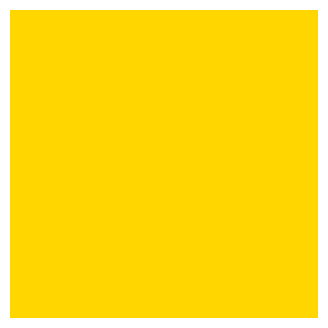

In [32]:
# Create a background that randomly samples a color from the Lab color space
lab_pixel = np.zeros((1, 1, 3), dtype=np.uint8)
lab_pixel[0,0] = [np.random.randint(255), np.random.randint(255), np.random.randint(255)]  # Example Lab color
# note: while LAB color space has L in [0, 100] and a,b in [-128, 127], OpenCV uses a scaled version where L is in [0, 255]
#  and a,b are in [0, 255]
lab_pixel[::,0]
rgb_pixel = cv2.cvtColor(lab_pixel, cv2.COLOR_LAB2RGB)

swatch = np.zeros((200, 200, 3), dtype=np.uint8)
swatch[:, :] = rgb_pixel[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(swatch)
plt.axis("off")
plt.show()

In [33]:
lab_pixel[0,0] = [np.random.randint(100), np.random.randint(255), np.random.randint(255)]  # Example Lab color
lab_pixel[::,0]

array([[ 65, 195, 201]], dtype=uint8)

# https://stackoverflow.com/questions/71865493/is-it-possible-to-create-a-random-shape-on-an-image-in-python
import cv2
import skimage.exposure
import numpy as np
from numpy.random import default_rng

# read input image
img = cv2.imread('lena.jpg')
height, width = img.shape[:2]

# define random seed to change the pattern
seedval = 75
rng = default_rng(seed=seedval)

# create random noise image
noise = rng.integers(0, 255, (height,width), np.uint8, True)

# blur the noise image to control the size
blur = cv2.GaussianBlur(noise, (0,0), sigmaX=15, sigmaY=15, borderType = cv2.BORDER_DEFAULT)

# stretch the blurred image to full dynamic range
stretch = skimage.exposure.rescale_intensity(blur, in_range='image', out_range=(0,255)).astype(np.uint8)

# threshold stretched image to control the size
thresh = cv2.threshold(stretch, 175, 255, cv2.THRESH_BINARY)[1]

# apply morphology open and close to smooth out and make 3 channels
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.merge([mask,mask,mask])

# add mask to input
result1 = cv2.add(img, mask)

# use canny edge detection on mask
edges = cv2.Canny(mask,50,255)

# thicken edges and make 3 channel
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
edges = cv2.morphologyEx(edges, cv2.MORPH_DILATE, kernel)
edges = cv2.merge([edges,edges,edges])

# merge edges with result1 (make black in result where edges are white)
result2 = result1.copy()
result2[np.where((edges == [255,255,255]).all(axis=2))] = [0,0,0]

# add noise to result where mask is white
noise = cv2.merge([noise,noise,noise])
result3 = result2.copy()
result3 = np.where(mask==(255,255,255), noise, result3)

# save result
cv2.imwrite('lena_random_blobs1.jpg', result1)
cv2.imwrite('lena_random_blobs2.jpg', result2)
cv2.imwrite('lena_random_blobs3.jpg', result3)

# show results
cv2.imshow('noise', noise)
cv2.imshow('blur', blur)
cv2.imshow('stretch', stretch)
cv2.imshow('thresh', thresh)
cv2.imshow('mask', mask)
cv2.imshow('edges', edges)
cv2.imshow('result1', result1)
cv2.imshow('result2', result2)
cv2.imshow('result3', result3)
cv2.waitKey(0)
cv2.destroyAllWindows()

- https://docs.opencv.org/3.4/df/d61/tutorial_random_generator_and_text.html
- https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html

In [34]:
from numpy.random import default_rng


def _sample_ceramic_bg(rng):
    """Sample a plausible ceramic matrix color in LAB; return BGR uint8 tuple."""
    if rng.random() < 0.1:  # 10% chance for dark grey
        # Dark grey in LAB (low L, neutral a/b)
        L = rng.integers(30, 70)
        a = rng.integers(120, 135)
        b = rng.integers(120, 135)
    else:
        L = rng.integers(120, 220)
        a = rng.integers(128, 165)
        b = rng.integers(135, 175)
    lab = np.array([[[L, a, b]]], dtype=np.uint8)
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return tuple(int(c) for c in bgr[0, 0])


def _keep_largest_component(mask):
    """Reduce a binary mask to its single largest connected component."""
    n_lbl, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_lbl <= 2:
        return mask
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = 1 + int(np.argmax(areas))
    return np.where(labels == largest, 255, 0).astype(np.uint8)


# --- Shape generators -------------------------------------------------------
# Calibrated against AMFOrA_public.core.detection envelopes.
#
# Inclusions (blob + polygon): solidity >~0.85, compactness >~0.4, aspect <=1.5:1.
#   Comfortably inside the inclusion gates (0.45 / 0.125 / 4:1).
# Voids: shorter sinuous traces resembling organic-burnout signatures.
#   Length 3-6x the radius parameter, thickness 0.22-0.40x, amplitude 10-25%
#   of length.  L/T ratio ~8-15.  At these proportions shape discrimination
#   against the inclusion list cannot be relied on post-blur+morph — the
#   void/inclusion split rests on contour_detection's symmetric
#   void_intensity_max brightness exclusion.  Longer traces (5-9x length)
#   also survive shape-wise but look cartoonishly worm-like in proportion.

def _blob_mask(rng, radius):
    """Round-ish inclusion: ellipse with mild axis ratio, optional rotation.

    Designed to pass blob and contour inclusion gates by construction.
    """
    side = 2 * radius + 4
    mask = np.zeros((side, side), dtype=np.uint8)
    cx, cy = side // 2, side // 2
    rx = radius
    ry = max(2, int(radius * rng.uniform(0.75, 1.0)))
    rot = float(rng.uniform(0, 180))
    cv2.ellipse(mask, (cx, cy), (rx, ry), rot, 0, 360, 255, -1)
    return mask


def _polygon_mask(rng, radius):
    """Angular inclusion: 4-8 sided polygon with modest vertex jitter.

    Jitter range chosen so aspect ratio stays under ~1.5:1 and solidity stays
    above ~0.85, well inside inclusion shape gates.
    """
    side = 2 * radius + 4
    mask = np.zeros((side, side), dtype=np.uint8)
    n_sides = int(rng.integers(4, 9))
    rot = rng.uniform(0, 2 * np.pi)
    cx, cy = side // 2, side // 2
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False) + rot
    jitter = rng.uniform(0.85, 1.15, size=n_sides)
    xs = (cx + radius * jitter * np.cos(angles)).astype(np.int32)
    ys = (cy + radius * jitter * np.sin(angles)).astype(np.int32)
    pts = np.stack([xs, ys], axis=1)
    cv2.fillPoly(mask, [pts], 255)
    return mask


def _void_mask(rng, radius):
    """Sinuous organic-burnout trace.

    Renders a thick curved polyline rather than a closed convex shape.
    Length 3-6x the radius parameter, thickness 0.22-0.40x, sinuous
    amplitude 10-25% of length.  Visual L/T ratio ~8-15.  Raw solidity
    ~0.50-0.70 and post-pipeline solidity ~0.70-0.95 — shape discrimination
    against the inclusion list cannot be relied on at these proportions, so
    the void/inclusion split rests on contour_detection's symmetric
    void_intensity_max brightness exclusion.
    """
    length = int(radius * rng.uniform(3.0, 6.0))
    thickness = max(3, int(radius * rng.uniform(0.22, 0.40)))
    amplitude = int(length * rng.uniform(0.10, 0.25))

    # Spine sampled along x-axis with low-frequency sinusoidal perturbation
    # so the trace curves like a coastline rather than zig-zagging.
    n_pts = max(20, length // 4)
    xs = np.linspace(-length / 2, length / 2, n_pts)
    ys = np.zeros(n_pts)
    n_harm = int(rng.integers(2, 5))
    for _ in range(n_harm):
        f = rng.uniform(0.5, 2.0)
        a = amplitude / n_harm * rng.uniform(0.5, 1.5)
        p = rng.uniform(0, 2 * np.pi)
        ys += a * np.sin(2 * np.pi * f * xs / length + p)

    # Rotate spine by a random angle.
    theta = rng.uniform(0, 2 * np.pi)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    xr = cos_t * xs - sin_t * ys
    yr = sin_t * xs + cos_t * ys

    # Canvas sized to the rotated extent + thickness pad.
    pad = thickness + 4
    w_extent = int(xr.max() - xr.min()) + 2 * pad
    h_extent = int(yr.max() - yr.min()) + 2 * pad
    side = max(w_extent, h_extent)
    cx_off = side // 2 - int((xr.max() + xr.min()) / 2)
    cy_off = side // 2 - int((yr.max() + yr.min()) / 2)

    mask = np.zeros((side, side), dtype=np.uint8)
    pts = np.stack(
        [(xr + cx_off).astype(np.int32), (yr + cy_off).astype(np.int32)],
        axis=1,
    )
    cv2.polylines(mask, [pts], isClosed=False, color=255,
                  thickness=thickness, lineType=cv2.LINE_8)
    return _keep_largest_component(mask)


# --- Color sampling ---------------------------------------------------------
# Material palettes for non-void inclusions, in OpenCV-scaled LAB (a,b
# centered at 128). Higher a = redder, higher b = yellower.
#
# All ranges are calibrated so the MINIMUM per-channel BGR intensity stays
# above the detector's void_intensity_max=60 cutoff with margin (~10+).
# This is what stops dark inclusions from being mis-classified as voids by
# the symmetric brightness gate — on real sherds dark mineral inclusions
# sit at interior >=73 even on light-grey paste; the palettes match that
# distribution rather than producing "blacker than any real mineral" colors.
# Heavy a/b saturation redistributes brightness across channels (warm
# colors suppress B, cool colors suppress R), so saturation upper bounds
# are tightened in tandem with lower L bounds.
_INCLUSION_PALETTES = [
    ((210, 250), (118, 135), (118, 138)),  # white shell / limestone
    ((80, 115),  (124, 132), (124, 132)),  # dark mineral grain (basalt, sand)
    ((100, 150), (120, 134), (120, 134)),  # mid grey stone
    ((120, 170), (138, 155), (140, 155)),  # terracotta grog
    ((105, 140), (130, 140), (135, 145)),  # dark brown organics / iron-rich
]

# Inclusions need pop >= ~25 (max-BGR core-vs-annulus delta) to pass the
# inclusion_pop_min gate. Sample-resampling target uses a comfortable margin.
_MIN_INCLUSION_BG_DELTA = 35

# Voids need interior mean intensity < void_intensity_max (default 60).
# We sample the absolute void L low enough that BGR comfortably passes.
_VOID_L_RANGE = (5, 40)


def _sample_inclusion_color(bg_bgr, kind, rng):
    """Sample BGR. Voids force a near-black target; inclusions resample if too close to bg."""
    if kind == "void":
        L = int(rng.integers(_VOID_L_RANGE[0], _VOID_L_RANGE[1] + 1))
        a = int(rng.integers(122, 134))
        b = int(rng.integers(122, 134))
        lab = np.array([[[L, a, b]]], dtype=np.uint8)
        bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        return tuple(int(c) for c in bgr[0, 0])

    bg_arr = np.array(bg_bgr, dtype=np.int32)
    best = None
    best_delta = -1
    for _ in range(12):
        L_r, a_r, b_r = _INCLUSION_PALETTES[int(rng.integers(0, len(_INCLUSION_PALETTES)))]
        L = int(rng.integers(L_r[0], L_r[1] + 1))
        a = int(rng.integers(a_r[0], a_r[1] + 1))
        b = int(rng.integers(b_r[0], b_r[1] + 1))
        lab = np.array([[[L, a, b]]], dtype=np.uint8)
        bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        cand = tuple(int(c) for c in bgr[0, 0])
        delta = int(np.max(np.abs(np.array(cand, dtype=np.int32) - bg_arr)))
        if delta >= _MIN_INCLUSION_BG_DELTA:
            return cand
        if delta > best_delta:
            best_delta = delta
            best = cand
    # Fallback: if no palette draw cleared the threshold, push to whichever
    # high-contrast extreme (white or dark-grey) is farther from the matrix.
    # Note: "dark" fallback is dark grey (90), not pure black, so it stays
    # above void_intensity_max on every channel.
    bg_mean = int(bg_arr.mean())
    return (250, 250, 250) if bg_mean < 128 else (90, 90, 90)


_KINDS = np.array(["blob", "polygon", "void"])
_KIND_WEIGHTS = np.array([0.60, 0.25, 0.15])
_MAX_TRIES = 50


def generate_ceramic_image(image_size, n_inclusions, size_range, seed):
    """Create a synthetic ceramic image with non-overlapping inclusions.

    Shapes and colors are calibrated so generated features fall inside the
    AMFOrA_public.core.detection envelopes (size, aspect, solidity,
    compactness, circularity/convexity, and intensity contrast).  Voids are
    rendered as sinuous traces (organic-burnout signatures) and rely on the
    detector's symmetric void_intensity_max brightness exclusion to avoid
    being double-counted as inclusions.

    Parameters
    ----------
    image_size : (H, W) in pixels
    n_inclusions : target count of inclusions to place
    size_range : (min_radius, max_radius) in pixels
        Used directly for blob/polygon inclusions; for voids the same value
        acts as a length-scale factor (the trace is 3-6x longer than this).
    seed : RNG seed for reproducibility

    Returns
    -------
    (image_bgr, label_mask_int32, metadata_dict)
    """
    H, W = image_size
    rng = default_rng(seed)
    bg = _sample_ceramic_bg(rng)
    image = np.full((H, W, 3), bg, dtype=np.uint8)
    label_mask = np.zeros((H, W), dtype=np.int32)
    inclusions = []
    skipped = 0
    rmin, rmax = size_range

    for i in range(1, n_inclusions + 1):
        radius = int(rng.integers(rmin, rmax + 1))
        kind = str(rng.choice(_KINDS, p=_KIND_WEIGHTS))
        if kind == "blob":
            shape = _blob_mask(rng, radius)
        elif kind == "polygon":
            shape = _polygon_mask(rng, radius)
        else:
            shape = _void_mask(rng, radius)
        sh, sw = shape.shape
        if sh >= H or sw >= W or shape.sum() == 0:
            skipped += 1
            continue
        color = _sample_inclusion_color(bg, kind, rng)

        placed = False
        for _ in range(_MAX_TRIES):
            # entire stamp strictly inside the frame, so shapes never touch the border
            x0 = int(rng.integers(0, W - sw))
            y0 = int(rng.integers(0, H - sh))
            region = label_mask[y0:y0 + sh, x0:x0 + sw]
            if np.any((shape > 0) & (region > 0)):
                continue
            ys, xs = np.where(shape > 0)
            image[y0 + ys, x0 + xs] = color
            label_mask[y0 + ys, x0 + xs] = i
            cx = x0 + int(xs.mean())
            cy = y0 + int(ys.mean())
            inclusions.append({
                "id": i,
                "kind": kind,
                "center": (cx, cy),
                "radius": radius,
                "color_bgr": color,
            })
            placed = True
            break
        if not placed:
            skipped += 1

    metadata = {
        "seed": seed,
        "image_size": (H, W),
        "background_bgr": bg,
        "inclusions": inclusions,
        "skipped": skipped,
    }
    return image, label_mask, metadata


def generate_ceramic_image_batch(n_images, seeds, image_size, n_inclusions, size_range):
    """Run generate_ceramic_image once per seed. Requires len(seeds) == n_images."""
    if len(seeds) != n_images:
        raise ValueError(f"len(seeds)={len(seeds)} does not match n_images={n_images}")
    return [
        generate_ceramic_image(image_size, n_inclusions, size_range, s)
        for s in seeds
    ]

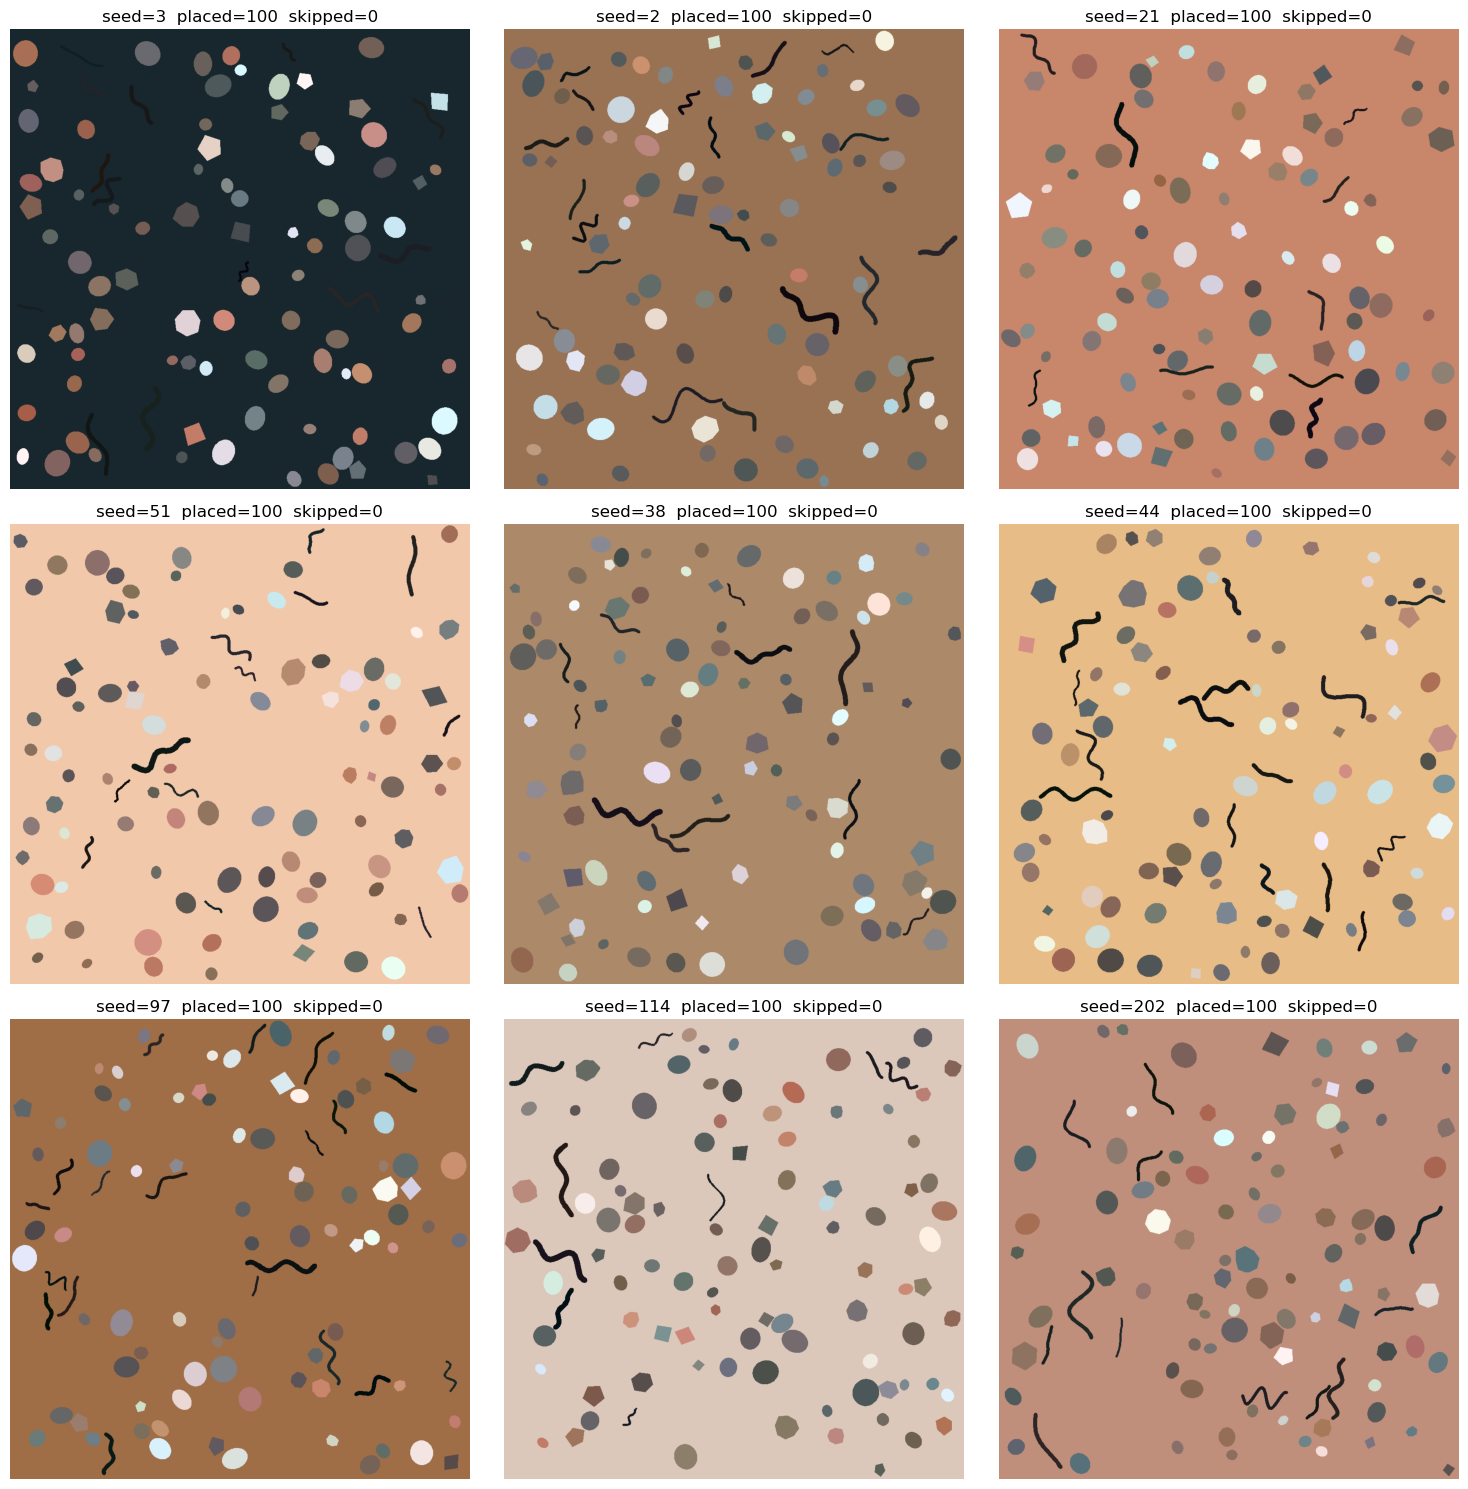

In [35]:
results = generate_ceramic_image_batch(
    n_images= 9,
    seeds=[3, 2 ,21, 51, 38, 44, 97, 114, 202],
    image_size=(1024, 1024),
    n_inclusions=100,
    size_range=(12, 30),
)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, (img, mask, meta) in zip(axes.flat, results):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"seed={meta['seed']}  placed={len(meta['inclusions'])}  skipped={meta['skipped']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [36]:
for result in results:
    img, mask, meta = result
    cv2.imwrite(f"pro_gen_imgs/ceramic_seed{meta['seed']}.png", img)

In [37]:
# ---- Setup & imports ----
import sys
from pathlib import Path

# Make the package importable from this notebook's location
proj_dir = Path('../..').resolve()
if str(proj_dir) not in sys.path:
    sys.path.insert(0, str(proj_dir))

# Auto-reload modules when source files change (no kernel restart needed)
%load_ext autoreload
%autoreload 2

import AMFOrA_public
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

print(f"AMFOrA_public loaded from: {AMFOrA_public.__file__}")
print(f"Version: {AMFOrA_public.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
AMFOrA_public loaded from: /Users/aiacobucci922/Documents/Python/AMACFA+/AMFOrA_public/__init__.py
Version: 1.0.0


In [58]:
# --- EDIT THESE ---

SINGLE_IMAGE = "/Users/aiacobucci922/Documents/Python/AMACFA+/AMFOrA_public/examples/pro_gen_imgs/ceramic_seed3.png"         # one sherd scan

SCAN_DPI     = 1200                              # scanner resolution
def imshow_cm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in centimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 2.54, h / dpi * 2.54, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("cm")
    ax.set_ylabel("cm")

def imshow_mm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in millimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 25.4, h / dpi * 25.4, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("mm")
    ax.set_ylabel("mm")

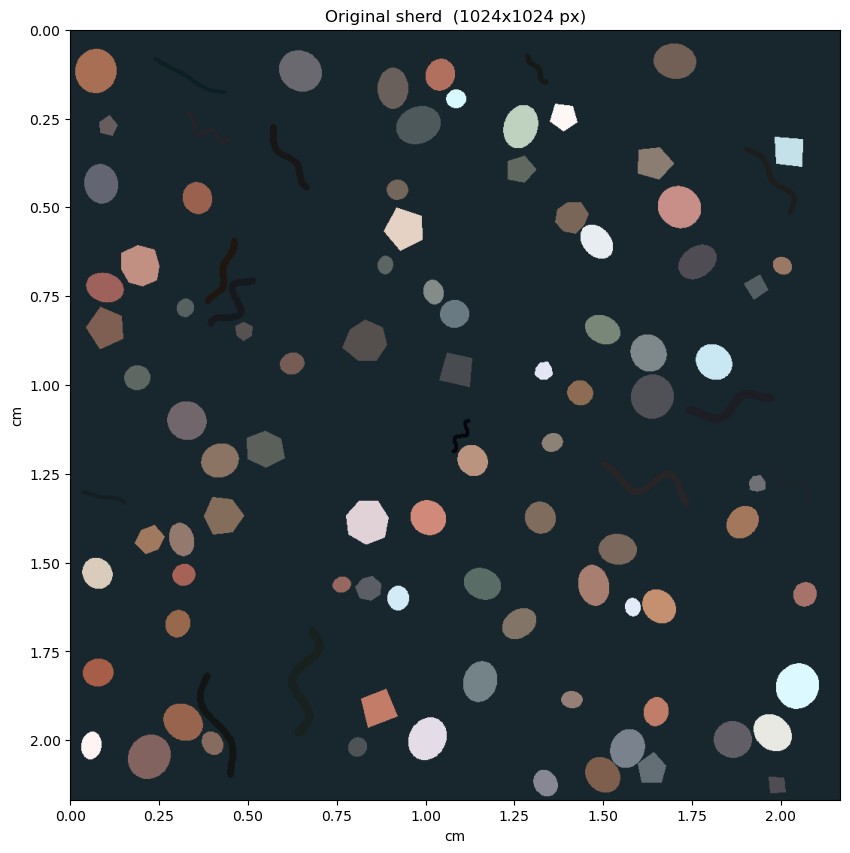

In [59]:
# Load and display the single image
img = cv2.imread(SINGLE_IMAGE)
assert img is not None, f"Could not load image: {SINGLE_IMAGE}"

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), img[:, :, ::-1])
plt.title(f"Original sherd  ({img.shape[1]}x{img.shape[0]} px)")
plt.show()

Inclusions detected: 84
Voids detected:      9


Text(0.5, 1.0, 'Inclusions (green): 84  |  Voids (red): 9')

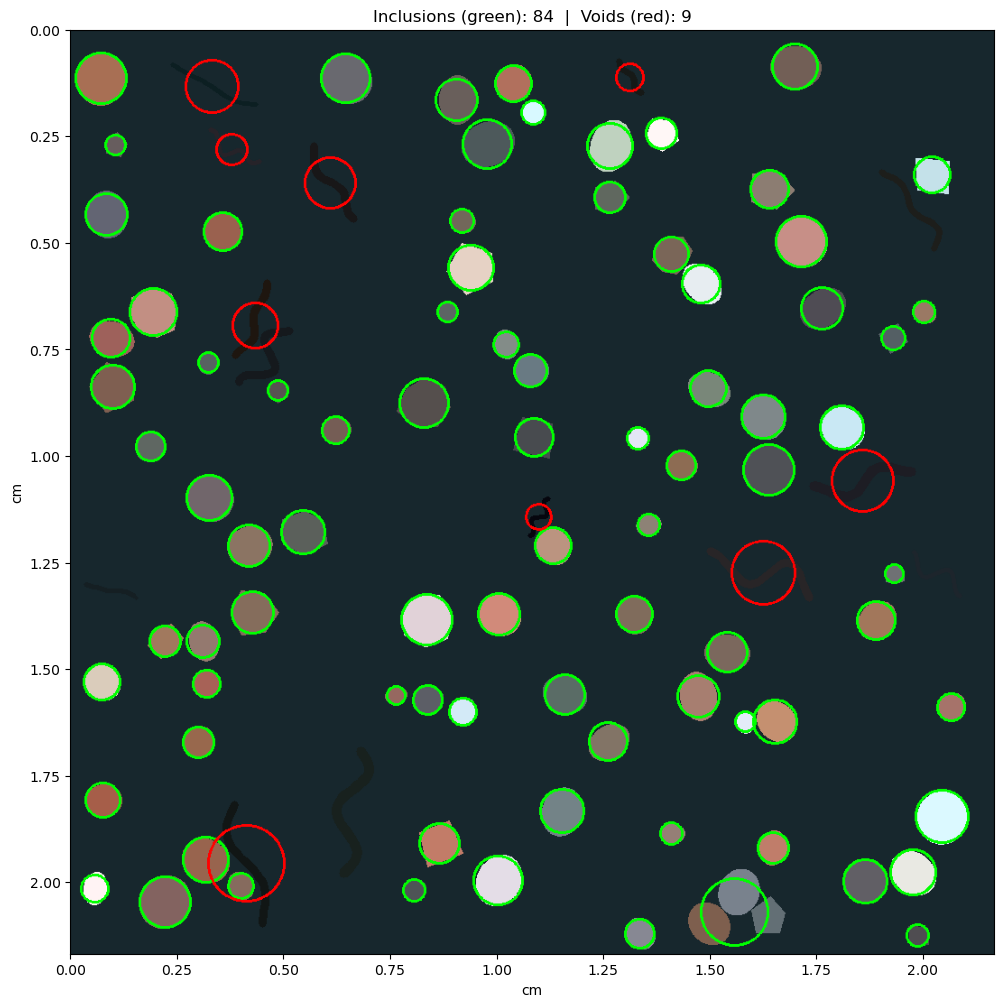

In [60]:
# sherd_blobs -- detect inclusions (light blobs) and voids (dark blobs)
inclusion_blobs, void_blobs = AMFOrA_public.sherd_blobs(img, scan_dpi=SCAN_DPI/2)
print(f"Inclusions detected: {len(inclusion_blobs)}")
print(f"Voids detected:      {len(void_blobs)}")

# Overlay blob circles on the masked image
overlay = img.copy()
for kp in inclusion_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 255, 0), 2)
for kp in void_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 0, 255), 2)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), overlay[:, :, ::-1])
plt.title(f"Inclusions (green): {len(inclusion_blobs)}  |  Voids (red): {len(void_blobs)}")

Contour inclusions: 73
Contour voids:      10


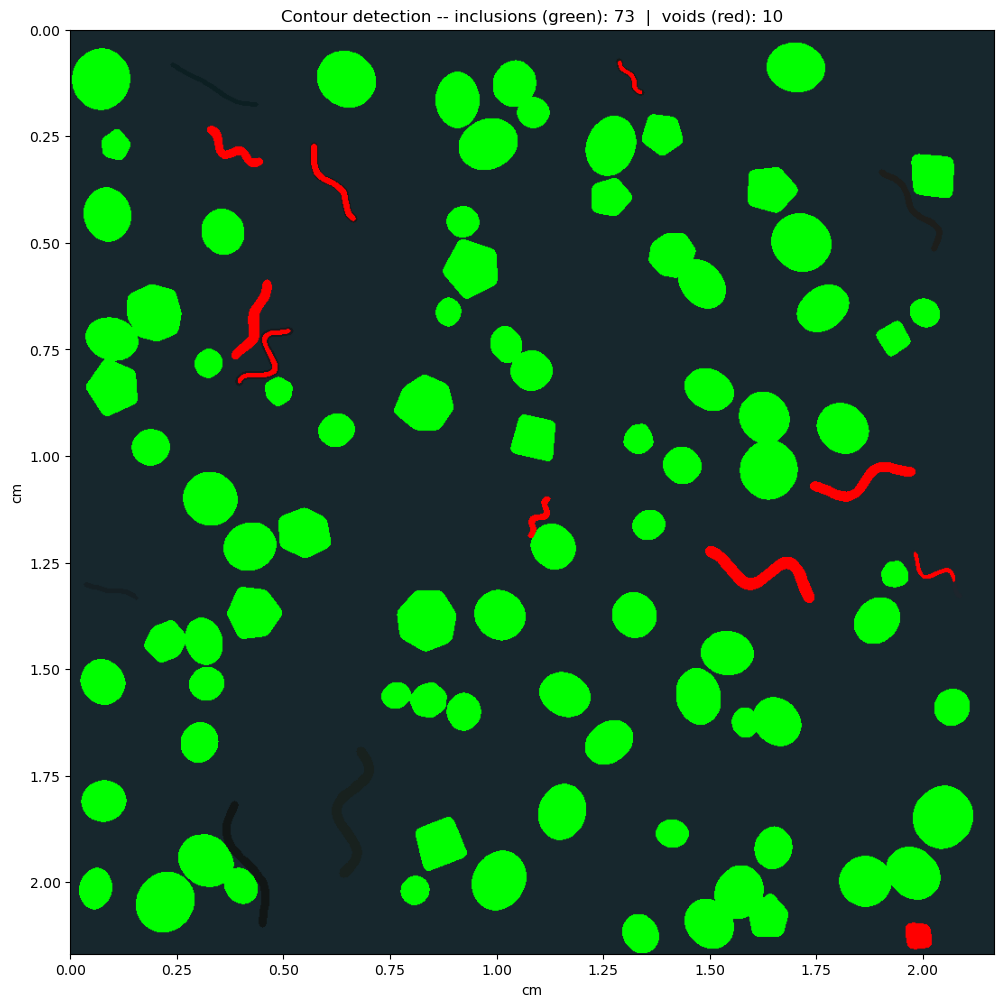

In [61]:
# contour_detection -- contour-based feature detection (better for angular/irregular shapes)
contour_results = AMFOrA_public.contour_detection(img, scan_dpi=SCAN_DPI)

print(f"Contour inclusions: {contour_results['total_inclusions']}")
print(f"Contour voids:      {contour_results['total_voids']}")

# Draw contours on the masked image
contour_img = img.copy()
cv2.drawContours(contour_img, contour_results['inclusions'], -1, (0, 255, 0), -1)
cv2.drawContours(contour_img, contour_results['voids'], -1, (0, 0, 255), -1)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), contour_img[:, :, ::-1])
plt.title(f"Contour detection -- inclusions (green): {contour_results['total_inclusions']}  |  voids (red): {contour_results['total_voids']}")
plt.show()


In [50]:
# --- EDIT THESE ---
IMAGE_DIR    = "/Users/aiacobucci922/Documents/Python/AMACFA+/AMFOrA_public/examples/pro_gen_imgs"   # folder with multiple sherd scans
SCAN_DPI     = 1200                              # scanner resolution


In [51]:
# full_analysis -- comprehensive batch analysis of all images in a directory
pro_gen_full = AMFOrA_public.full_analysis(IMAGE_DIR, scan_dpi=SCAN_DPI, analyze_core_periphery=True, save_csv=True, output_filename="pro_gen_full_analysis.csv", pre_masked=True)
display(pro_gen_full)

Starting full analysis of 9 ceramic sherds...
Using scan DPI: 1200
Detection methods: Blob + Contour
Analyzing inclusions: True
Analyzing voids: True
--------------------------------------------------
Processing ceramic_seed21.png (1/9)
  Success - Blob: 88 inclusions, Contour: 89 inclusions
Processing ceramic_seed44.png (2/9)
  Success - Blob: 85 inclusions, Contour: 88 inclusions
Processing ceramic_seed51.png (3/9)
  Success - Blob: 88 inclusions, Contour: 106 inclusions
Processing ceramic_seed97.png (4/9)
  Success - Blob: 78 inclusions, Contour: 79 inclusions
Processing ceramic_seed114.png (5/9)
  Success - Blob: 88 inclusions, Contour: 85 inclusions
Processing ceramic_seed38.png (6/9)
  Success - Blob: 87 inclusions, Contour: 89 inclusions
Processing ceramic_seed202.png (7/9)
  Success - Blob: 87 inclusions, Contour: 91 inclusions
Processing ceramic_seed2.png (8/9)
  Success - Blob: 77 inclusions, Contour: 77 inclusions
Processing ceramic_seed3.png (9/9)
  Success - Blob: 82 inclu

,filename,file_path,scan_dpi,analysis_status,sherd_area_cm2,blob_inclusion_count,blob_inclusion_total_area_cm2,blob_inclusion_mean_area_cm2,blob_inclusion_std_area_cm2,blob_inclusion_min_area_cm2,...,inner_margin_color_b,outer_margin_color_l,outer_margin_color_a,outer_margin_color_b,core_atmosphere,inner_margin_atmosphere,outer_margin_atmosphere,core_periphery_gradient,firing_interpretation,margin_symmetry
0,ceramic_seed21.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,88,0.558573,0.006347,0.002879,0.001544,...,150.0,156.0,148.0,150.0,oxidized,oxidized,oxidized,2.449490,fully_oxidized,symmetric
1,ceramic_seed44.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,85,0.540551,0.006359,0.004964,0.001196,...,159.0,195.0,136.0,159.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,3.000000,incomplete_oxidation,symmetric
2,ceramic_seed51.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,88,0.509668,0.005792,0.002959,0.001405,...,146.0,205.0,138.0,146.0,oxidized,oxidized,oxidized,2.828427,fully_oxidized,symmetric
3,ceramic_seed97.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,78,0.442967,0.005679,0.003135,0.001838,...,155.0,131.0,142.0,155.0,oxidized,oxidized,oxidized,2.236068,fully_oxidized,symmetric
4,ceramic_seed114.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,88,0.493103,0.005603,0.002839,0.001835,...,136.0,201.0,133.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,2.828427,incomplete_oxidation,symmetric
5,ceramic_seed38.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,87,0.517189,0.005945,0.003349,0.001730,...,149.0,148.0,136.0,148.0,oxidized,incomplete_oxidation,incomplete_oxidation,3.162278,fully_oxidized,symmetric
6,ceramic_seed202.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,87,0.509248,0.005853,0.003310,0.001434,...,144.0,157.0,142.0,145.0,oxidized,oxidized,oxidized,1.732051,fully_oxidized,symmetric
7,ceramic_seed2.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,77,0.496851,0.006453,0.002828,0.001872,...,149.0,131.0,138.0,148.0,oxidized,oxidized,oxidized,2.236068,fully_oxidized,symmetric
8,ceramic_seed3.png,/Users/aiacobucci922/Documents/Python/AMACFA+/...,1200,success,4.697931,82,0.526965,0.006426,0.003487,0.001674,...,123.0,50.0,124.0,124.0,carbonaceous,carbonaceous,carbonaceous,2.449490,carbonaceous_throughout,symmetric


In [62]:
np.mean([pro_gen_full['blob_inclusion_count'], pro_gen_full['contour_inclusion_count']])

85.38888888888889

In [53]:
pro_gen_full[['blob_inclusion_count', 'contour_inclusion_count', 'blob_void_count', 'contour_void_count']]

,blob_inclusion_count,contour_inclusion_count,blob_void_count,contour_void_count
0,88,89,0,8
1,85,88,0,13
2,88,106,0,1
3,78,79,3,19
4,88,85,0,3
5,87,89,0,10
6,87,91,0,5
7,77,77,0,20
8,82,73,7,10
